In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Set dataset paths
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/augmented"  # Change this to your dataset path
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

# Ensure paths exist
if os.path.exists(BASE_DIR):
    print("✅ Dataset directory found!")
else:
    print("❌ Dataset directory NOT found. Check your path.")
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
import shutil
from sklearn.model_selection import train_test_split

# Define paths
base_path = "/content/drive/My Drive/Colab Notebooks/cataract_dataset"
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

# Function to count images in a folder
def count_images(folder_path):
    count = {}
    for category in os.listdir(folder_path):
        category_path = os.path.join(folder_path, category)
        if os.path.isdir(category_path):
            count[category] = len(os.listdir(category_path))
    return count

# Get image counts
train_counts = count_images(train_path)
test_counts = count_images(test_path)

# Print results
print("Train set image counts:", train_counts)
print("Test set image counts:", test_counts)




Mounted at /content/drive
✅ Dataset directory found!
Train set image counts: {'cataract': 3760, 'normal': 3779}
Test set image counts: {'cataract': 940, 'normal': 945}


In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load Pre-trained ResNet50 model (without the classification head)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Define dataset path (training folder)
dataset_path = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/train"

# Function to extract features
def extract_features(directory):
    data = []
    labels = []

    for category in os.listdir(directory):  # Cataract, Normal
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                img_path = os.path.join(category_path, img_name)

                # Load and preprocess image
                img = load_img(img_path, target_size=(224, 224))
                img_array = img_to_array(img)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = preprocess_input(img_array)  # Normalize for ResNet50

                # Extract features
                features = base_model.predict(img_array)
                features = features.flatten()  # Flatten the feature map

                # Append to data
                data.append(features)
                labels.append(1 if category.lower() == "cataract" else 0)

    return np.array(data), np.array(labels)

# Extract features
X, y = extract_features(dataset_path)
print(f"Feature shape for last image: {X[-1].shape}")

# Convert to DataFrame
df = pd.DataFrame(X)
df['label'] = y

# Save CSV
csv_path = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/cataract_resnet_train_features.csv"
df.to_csv(csv_path, index=False)

print(f"✅ CSV saved at: {csv_path}")
print(df.head())
print("Unique train labels:", np.unique(y))


Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import pandas as pd

# Path to your ResNet Feature Extracted CSV
csv_path = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/cataract_resnet_train_features.csv"

# Load only the label column
df = pd.read_csv(csv_path, usecols=['label'])

# Check unique labels
unique_labels = df['label'].unique()
print(f"✅ Unique labels in dataset: {unique_labels}")

# Count of each label
label_counts = df['label'].value_counts()
print("\n📊 Label distribution:")
print(label_counts)


✅ Unique labels in dataset: [1 0]

📊 Label distribution:
label
0    3779
1    3760
Name: count, dtype: int64


test data feature extraction

In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load Pre-trained ResNet50 model (without the classification head)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Define dataset path
dataset_path = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/test"

# Function to extract features
def extract_features(directory):
    data = []
    labels = []

    for category in os.listdir(directory):  # Cataract, Normal
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                img_path = os.path.join(category_path, img_name)

                # Load image and preprocess
                img = load_img(img_path, target_size=(224, 224))
                img_array = img_to_array(img)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = preprocess_input(img_array)  # Normalize for ResNet50

                # Extract features
                features = base_model.predict(img_array)
                features = features.flatten()  # Flatten the feature map

                # Append to data
                data.append(features)
                labels.append(1 if category.lower() == "cataract" else 0)  # Label (Cataract or Normal)

    return np.array(data), np.array(labels)

# Extract features from dataset
X, y = extract_features(dataset_path)

# Convert to DataFrame
df = pd.DataFrame(X)
df['label'] = y  # Add labels

# Save as CSV
csv_path = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/cataract_test_features_resnet.csv"
df.to_csv(csv_path, index=False)

print(f"✅ CSV saved at: {csv_path}")
print(df.head())  # Print sample rows


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━

In [ ]:
import pandas as pd

# Path to your ResNet Feature Extracted CSV
csv_path = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/cataract_test_features_resnet.csv"

# Load only the label column
df = pd.read_csv(csv_path, usecols=['label'])

# Check unique labels
unique_labels = df['label'].unique()
print(f"✅ Unique labels in dataset: {unique_labels}")

# Count of each label
label_counts = df['label'].value_counts()
print("\n📊 Label distribution:")
print(label_counts)



✅ Unique labels in dataset: [1 0]

📊 Label distribution:
label
0    945
1    940
Name: count, dtype: int64


MLP train


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping


train_path = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/cataract_resnet_train_features.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/cataract_test_features_resnet.csv"
train_df = pd.read_csv(train_path)  # Load train data
test_df = pd.read_csv(test_path)
# Read CSV files
train_df['label'] = train_df['label'].map({'cataract': 1, 'normal': 0})
test_df['label'] = test_df['label'].map({'cataract': 1, 'normal': 0})
'''
# ✅ 2. Prepare Data
X_train = train_df.drop(columns=["label"]).values  # Drop label column, keep features
y_train = train_df["label"].astype(int).values  # Convert labels to integers

X_test = test_df.drop(columns=["label"]).values
# ✅ Convert label column to integers (if categorical)
y_test = test_df["label"].astype(int).values'''

X_train, y_train = train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values
X_test, y_test = test_df.iloc[:, :-1].values, test_df.iloc[:, -1].values
# Normalize Data
X_train = X_train / np.max(X_train)
X_test = X_test / np.max(X_test)

# ✅ 3. Define MLP Model
model = Sequential([
    Dense(64, activation="relu", kernel_regularizer=l2(0.005), input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation="relu", kernel_regularizer=l2(0.005)),
    Dropout(0.3),
    Dense(1, activation="sigmoid")  # Binary classification
])

# ✅ Define Optimizer with Learning Rate
optimizer = Adam(learning_rate=0.0001)

# ✅ 4. Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ✅ 5. Train Model
early_stopping = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

# ✅ Train Model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,   # ✅ Limit epochs to 10
    batch_size=64,  # ✅ Ensure reasonable batch size
    callbacks=[early_stopping],
    verbose=1)
# ✅ 6. Save Model for Future Use
model.save("/content/drive/MyDrive/Colab Notebooks/cataract_dataset/mlp_resnet_model.h5")

# ✅ 7. Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

# 🔹 Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Test Accuracy', marker='s', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs. Test Accuracy')
plt.legend()

# 🔹 Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Test Loss', marker='s', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs. Test Loss')
plt.legend()

plt.show()


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ✅ Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# ✅ Load Data
train_path = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/cataract_resnet_train_features.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/cataract_test_features_resnet.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# ⚠️ Only map labels if they are in text like 'cataract'/'normal'
# Here labels are already 0 and 1 → So skip mapping!

# ✅ Split Features and Labels
X_train, y_train = train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values
X_test, y_test = test_df.iloc[:, :-1].values, test_df.iloc[:, -1].values

# ✅ Normalize features
max_value = np.max(X_train)  # Same scaling for both
X_train = X_train / max_value
X_test = X_test / max_value

# ✅ Define MLP Model
model = Sequential([
    Dense(128, activation='relu', kernel_regularizer=l2(0.005), input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.005)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Output layer for Binary classification
])

# ✅ Compile Model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ✅ Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# ✅ Train Model
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=64,
                    callbacks=[early_stop],
                    verbose=1)
model.save('/content/drive/MyDrive/Colab Notebooks/cataract_dataset/mlp_resnet_model.h5')


# ✅ Evaluate on Test Data
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc * 100:.2f}%")

# ✅ Plot Loss Curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

# ✅ Plot Accuracy Curve
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.9 MB/s eta 0:00:00
Mounted at /content/drive


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 36s 340ms/step - accuracy: 0.7889 - loss: 1.1063 - val_accuracy: 0.9138 - val_loss: 0.6659
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 29s 308ms/step - accuracy: 0.9143 - loss: 0.5519 - val_accuracy: 0.9509 - val_loss: 0.4507
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 29s 300ms/step - accuracy: 0.9318 - loss: 0.4664 - val_accuracy: 0.9450 - val_loss: 0.4485
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 29s 295ms/step - accuracy: 0.9417 - loss: 0.4243 - val_accuracy: 0.9443 - val_loss: 0.4176
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 29s 295ms/step - accuracy: 0.9357 - loss: 0.4107 - val_accuracy: 0.9483 - val_loss: 0.3872
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 29s 296ms/step - accuracy: 0.9425 - loss: 0.3897 - val_accuracy: 0.9483 - val_loss: 0.3723
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 28s 292ms/step - accuracy: 0.9518 - loss: 0.3601 - val_accuracy: 0.9463 - val_loss: 0.3702
Epoch 8/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 27s 285ms/step - accuracy: 0.9489 - loss: 0.3462 - val_accu

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9426 - loss: 0.3068
Test Accuracy: 95.60%


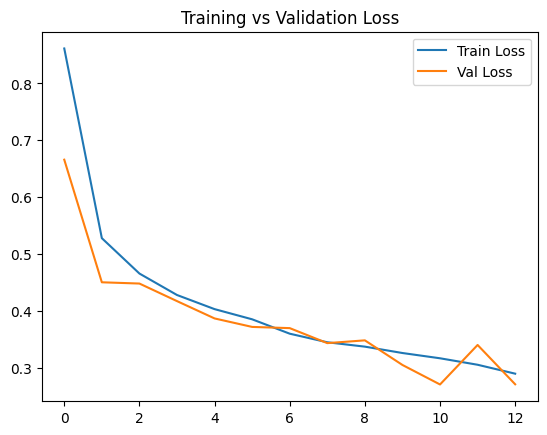

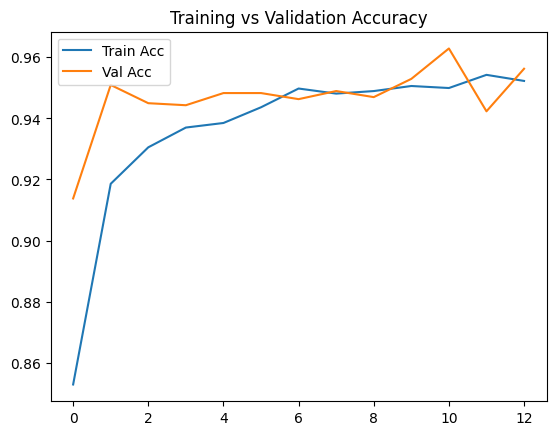

In [ ]:
!pip install tensorflow
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ✅ Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# ✅ Load Data
train_path = "/content/drive/MyDrive/Colab Notebooks/cataract_resnet_train_features.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/cataract_test_features_resnet.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# ⚠️ Only map labels if they are in text like 'cataract'/'normal'
# Here labels are already 0 and 1 → So skip mapping!

# ✅ Split Features and Labels
X_train, y_train = train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values
X_test, y_test = test_df.iloc[:, :-1].values, test_df.iloc[:, -1].values

# ✅ Normalize features
max_value = np.max(X_train)  # Same scaling for both
X_train = X_train / max_value
X_test = X_test / max_value

# ✅ Define MLP Model
model = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.005), input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.005)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Output layer for Binary classification
])

# ✅ Compile Model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ✅ Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# ✅ Train Model
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=64,
                    callbacks=[early_stop],
                    verbose=1)
model.save('/content/drive/MyDrive/Colab Notebooks/mlp_resnet_model.h5')


# ✅ Evaluate on Test Data
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc * 100:.2f}%")

# ✅ Plot Loss Curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

# ✅ Plot Accuracy Curve
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()


resnet50+mlp evaluation


In [ ]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---- Load test features from CSV ----
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cataract_test_features_resnet.csv")

# ---- Load trained MLP model correctly ----
mlp_model = load_model("/content/drive/MyDrive/Colab Notebooks/mlp_resnet_model.h5")

# ✅ Check if labels need mapping before applying
# If labels are already 0 and 1, this step is skipped.
if df_test['label'].dtype == object:  # If labels are strings (like 'cataract', 'normal')
    df_test['label'] = df_test['label'].map({'cataract': 1, 'normal': 0})

# ---- Split features and labels ----
X_test = df_test.iloc[:, :-1].values  # Features
y_test = df_test.iloc[:, -1].values   # Labels

# ---- Predict test set ----
y_pred = mlp_model.predict(X_test)

# ---- Convert probability predictions to binary (0 or 1) ----
y_pred = (y_pred >= 0.5).astype(int)  # Threshold at 0.5
# ---- Flatten predictions ----
y_pred = y_pred.flatten().astype(int)

# ---- Evaluate performance ----
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Test Accuracy: {accuracy * 100:.2f}%")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Cataract"]))

print("\n🔹 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
🎯 Test Accuracy: 95.60%

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96       945
    Cataract       0.96      0.96      0.96       940

    accuracy                           0.96      1885
   macro avg       0.96      0.96      0.96      1885
weighted avg       0.96      0.96      0.96      1885


🔹 Confusion Matrix:
[[904  41]
 [ 42 898]]


roc-auc

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

📈 ROC AUC Score: 0.9661


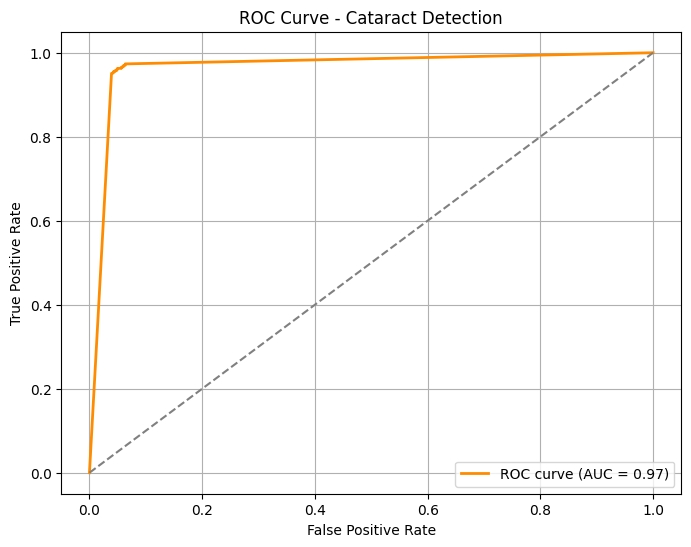

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from tensorflow.keras.models import load_model

# ---- Load test data ----
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cataract_dataset/cataract_test_features_resnet.csv")
mlp_model = load_model("/content/drive/MyDrive/Colab Notebooks/cataract_dataset/mlp_resnet_model.h5")

# ---- Convert string labels if needed ----
if df_test['label'].dtype == object:
    df_test['label'] = df_test['label'].map({'cataract': 1, 'normal': 0})

# ---- Separate features and labels ----
X_test = df_test.iloc[:, :-1].values
y_test = df_test.iloc[:, -1].values

# ---- Predict probabilities ----
y_pred_proba = mlp_model.predict(X_test)

# ---- Convert probabilities to binary predictions ----
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

# ---- ROC Curve and AUC ----
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n📈 ROC AUC Score: {auc:.4f}")

# ---- Plot ROC Curve ----
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Cataract Detection")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


testing

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image

# Load trained MLP model
mlp_model = load_model("/content/drive/MyDrive/Colab Notebooks/cataract_dataset/mlp_resnet_model.h5")

# Load ResNet model (feature extractor only)
# Use the same configuration as during training (likely without pooling)
resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Load and preprocess image
img_path = '/content/drive/MyDrive/Colab Notebooks/cataract_dataset/augmented/cataract/0_left.png'  # change to your image path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Extract features using ResNet
features = resnet.predict(img_array)
# Flatten features to match the expected input shape of your MLP model
features = features.flatten()
features = features.reshape(1, -1)  # Reshape to (1, num_features)

# Predict using MLP
pred = mlp_model.predict(features)
pred_label = (pred >= 0.5).astype(int).flatten()[0]

# Output Result
if pred_label == 1:
    print("Prediction: 🩺 Cataract Detected")
else:
    print("Prediction: 👀 Normal Eye")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Prediction: 🩺 Cataract Detected


PErformance Comparison VGG+MLP VS RESNET50+MLP


59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


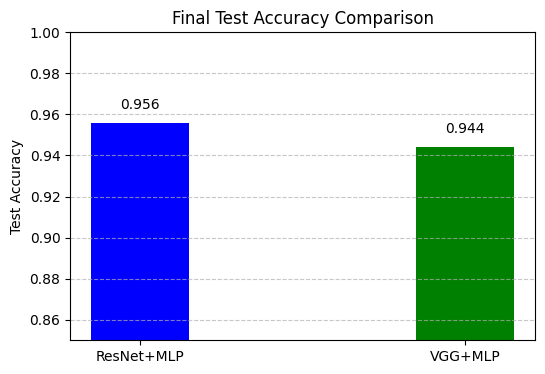

In [ ]:
import pandas as pd # Import pandas
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score
# Load ResNet test data
df_test_resnet = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cataract_dataset/cataract_test_features_resnet.csv")
if df_test_resnet['label'].dtype == object:
    df_test_resnet['label'] = df_test_resnet['label'].map({'cataract': 1, 'normal': 0})
X_test_resnet = df_test_resnet.iloc[:, :-1].values
y_test_resnet = df_test_resnet.iloc[:, -1].values

# Load VGG test data
df_test_vgg = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cataract_test_features.csv")
if df_test_vgg['label'].dtype == object:
    df_test_vgg['label'] = df_test_vgg['label'].map({'cataract': 1, 'normal': 0})
X_test_vgg = df_test_vgg.iloc[:, :-1].values
y_test_vgg = df_test_vgg.iloc[:, -1].values

# Load both models
resnet_model = load_model("/content/drive/MyDrive/Colab Notebooks/cataract_dataset/mlp_resnet_model.h5")
vgg_model    = load_model("/content/drive/MyDrive/Colab Notebooks/cataract_dataset/mlp_vgg_model.h5")

# Predict and evaluate
y_pred_resnet = (resnet_model.predict(X_test_resnet) >= 0.5).astype(int).flatten()
y_pred_vgg    = (vgg_model.predict(X_test_vgg) >= 0.5).astype(int).flatten()

from sklearn.metrics import accuracy_score
resnet_acc = accuracy_score(y_test_resnet, y_pred_resnet)
vgg_acc    = accuracy_score(y_test_vgg, y_pred_vgg)

import matplotlib.pyplot as plt

# Example accuracies
resnet_acc = 0.9560
vgg_acc = 0.9443

models = ['ResNet+MLP', 'VGG+MLP']
accuracy = [resnet_acc, vgg_acc]

plt.figure(figsize=(6,4))
bars = plt.bar(models, accuracy, width=0.3, color=['blue', 'green'])

plt.ylabel('Test Accuracy')
plt.title('Final Test Accuracy Comparison')
plt.ylim(0.85, 1.0)  # zoom into the accuracy range
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Optional: Show exact value on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', ha='center', va='bottom')

plt.show()


